### Transfer Learning

**Transfer Learning** is the process of taking a neural network that has already been trained on a massive dataset (like Google training a model on 14 million images for a month) and repurposing its "brain" to solve a new, specific problem.

---

### Phase 1: Feature Extraction (The "Frozen" Approach)

* **Definition:** You take the pre-trained model (the "Base") and **freeze** all of its weights so they cannot be changed. You slice off its final classification layer, and attach a brand-new, untrained "Head" (Dense layers) on top.
* **How it works:** During training, the Base acts purely as a scanner. It looks at your images and extracts features (lines, curves, dog ears, car wheels) using the knowledge it learned from Google's massive dataset. Only your brand-new Head is being trained to say according to the new data.
* **When to use it:** Always start here. It is lightning fast and prevents your untrained Head from sending massive, chaotic error gradients down into the Base and destroying its pre-trained knowledge.

### Phase 2: Fine-Tuning (The "Thawing" Approach)

* **Definition:** After your new Head has been trained (Feature Extraction is complete), you **unfreeze** the top few layers of the pre-trained Base model. You then train the *entire* network together for a few more epochs.
* **How it works:** You must use a **microscopically small learning rate** (e.g., `1e-5`). You are telling the model: *"You already know how to identify general shapes, but I want you to slightly adjust your internal lenses to focus specifically on the shapes in my dataset."*
* **When to use it:** Use this *only* after Feature Extraction is done, and only if you want to squeeze out the last 2-3% of accuracy.

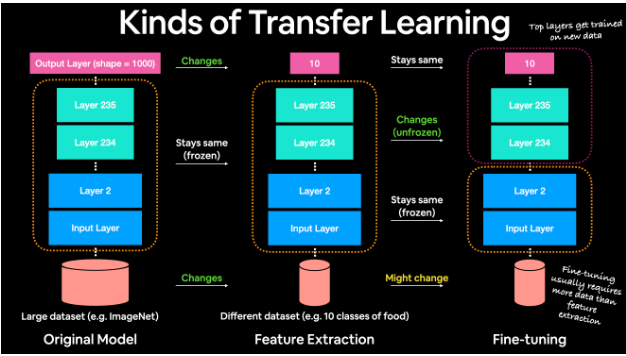
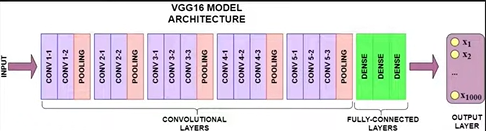

In [25]:
import os
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

In [27]:
_URL = 'https://download.microsoft.com'

path_to_zip = tf.keras.utils.get_file(
    'cats_and_dogs.zip', 
    origin=_URL,         
    extract=True         
)

PATH = os.path.join(os.path.dirname(path_to_zip), 'cats_and_dogs_filtered')

dataset_path = os.path.join(PATH, 'train')

176926/176926 ━━━━━━━━━━━━━━━━━━━━ 1s 3us/step


C:\Users\Hp\AppData\Local\Temp\ipykernel_1592\932797233.py:3: UserWarning: Could not extract archive.
  path_to_zip = tf.keras.utils.get_file(


In [ ]:
base = VGG16(
    weights='imagenet',
    include_top=False, # Remove Dense layer 
    input_shape=(150,150,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 25s 0us/step


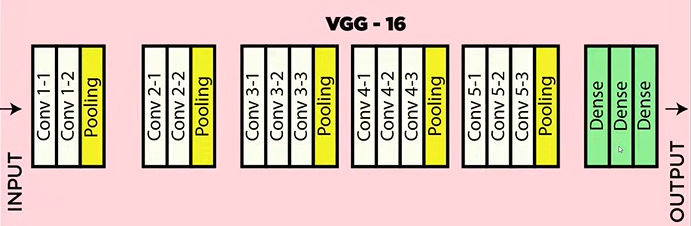

In [12]:
base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model = Sequential([
    base,
    Flatten(),
    Dense(256,activation='relu'),
    Dense(1,activation='sigmoid')
])

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 16,812,353 (64.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
dataset_path = './dataset' 

IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

print("Loading training data...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    labels='inferred',
    label_mode='int',
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH), 
    batch_size=BATCH_SIZE
)

print("Loading validation data...")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    labels='inferred',
    label_mode='int',
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH), 
    batch_size=BATCH_SIZE
)

Loading training data...
Found 0 files belonging to 0 classes.
Using 0 files for training.


ValueError: No images found in directory ./dataset/train. Allowed formats: ('.bmp', '.gif', '.jpeg', '.jpg', '.png')

In [ ]:
#Normalize
def process(image,label):
    image = tf.cast(image/255.,tf.float32)
    return image,label

train_dataset = train_dataset.map(process)
val_dataset - val_dataset.map(process)

In [24]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
record = model.fit(train_dataset,validation_data=val_dataset)